In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("../data/raw/anime_reviews.csv")

In [3]:
binary_df = df.copy()

binary_df = binary_df[
    ~binary_df["score"].isin([6, 7])
]

binary_df["binary_sentiment"] = binary_df["score"].apply(
    lambda x: "Positive" if x >= 8 else "Negative"
)

In [4]:
import joblib

In [5]:
model = joblib.load(
    "../artifacts/sentiment_model.pkl"
)

vectorizer = joblib.load(
    "../artifacts/tfidf_vectorizer.pkl"
)

In [6]:
print(type(model))
print(type(vectorizer))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [9]:
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [10]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

In [12]:
def preprocess_text(text):

    text = clean_text(text)

    tokens = word_tokenize(text)

    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

In [13]:
def predict_sentiment(review):
    
    processed = preprocess_text(review)

    vectorized = vectorizer.transform(
        [processed]
    )

    prediction = model.predict(
        vectorized
    )[0]

    probability = model.predict_proba(
        vectorized
    ).max()

    return prediction, probability

In [14]:
review = """
This anime was an absolute masterpiece.
The story was emotional, the animation
was beautiful, and every episode kept
me hooked.
"""

prediction, confidence = predict_sentiment(
    review
)

print(prediction)
print(confidence)

Positive
0.7805485080255019


In [15]:
negative_review = """
The story was boring and predictable.
The characters were annoying,
the pacing was terrible,
and the ending made absolutely no sense.
"""

In [16]:
prediction, confidence = predict_sentiment(
    negative_review
)

print(prediction)
print(confidence)

Negative
0.8475628336438709


In [17]:
feature_names = vectorizer.get_feature_names_out()

print(len(feature_names))
print(feature_names[:20])

1000
['ability' 'able' 'absolutely' 'academia' 'across' 'act' 'acting' 'action'
 'actor' 'actual' 'actually' 'adaptation' 'add' 'addition' 'admit'
 'adventure' 'age' 'ago' 'alchemist' 'almost']


In [18]:
import pandas as pd

coef_df = pd.DataFrame({
    "word": feature_names,
    "weight": model.coef_[0]
})

In [19]:
coef_df.sort_values(
    "weight",
    ascending=False
).head(20)

,word,weight
748,season,2.290485
823,steinsgate,1.546082
27,amazing,1.539076
518,love,1.482019
375,great,1.329859
643,perfect,1.328464
93,bit,1.262408
959,well,1.211590
827,story,1.208662
978,world,1.131329


In [20]:
coef_df.sort_values(
    "weight",
    ascending=True
).head(20)

,word,weight
101,boring,-2.039793
605,nothing,-1.483513
662,plot,-1.479065
66,bad,-1.467188
683,problem,-1.395974
850,supposed,-1.393947
634,overrated,-1.380367
262,even,-1.328650
472,kirito,-1.309679
548,mediocre,-1.278530


In [21]:
positive_reviews = binary_df[
    binary_df["binary_sentiment"] == "Positive"
]

negative_reviews = binary_df[
    binary_df["binary_sentiment"] == "Negative"
]

In [ ]:
positive_text = " ".join(
    positive_reviews["processed_review"]
)

negative_text = " ".join(
    negative_reviews["processed_review"]
)

In [23]:
print(binary_df.columns.tolist())

['review_id', 'anime_mal_id', 'anime_title', 'username', 'score', 'tags', 'review_text', 'date', 'episodes_watched', 'is_spoiler', 'is_preliminary', 'reactions_overall', 'reactions_nice', 'reactions_love_it', 'reactions_funny', 'reactions_confusing', 'reactions_informative', 'reactions_well_written', 'reactions_creative', 'binary_sentiment']


In [24]:
binary_df["processed_review"] = (
    binary_df["review_text"]
    .apply(preprocess_text)
)

In [25]:
binary_df[
    ["review_text", "processed_review"]
].head()

,review_text,processed_review
0,Makoto Shinkai's The Garden of Words is one of...,makoto shinkais garden word one film earns wor...
1,Y con es termino de ver todas las peliculas de...,con e termino de ver toda la peliculas de mi d...
2,My honest opinion on K-ON!: I absolutely LOVE ...,honest opinion kon absolutely love show yui hi...
3,"Uh, I don't even even know where to start. Hon...",uh dont even even know start honestly ive neve...
4,"""FLCL"" both walks and works only on a thin lin...",flcl walk work thin line genius insanity would...


In [26]:
positive_reviews = binary_df[
    binary_df["binary_sentiment"] == "Positive"
]

negative_reviews = binary_df[
    binary_df["binary_sentiment"] == "Negative"
]

positive_text = " ".join(
    positive_reviews["processed_review"]
)

negative_text = " ".join(
    negative_reviews["processed_review"]
)

In [27]:
## WordCloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [28]:
positive_wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(positive_text)

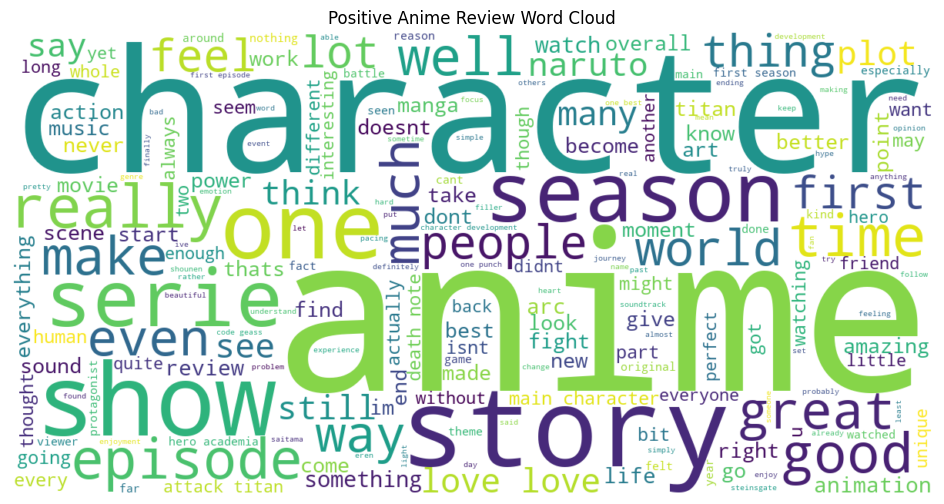

In [29]:
plt.figure(figsize=(12, 6))

plt.imshow(
    positive_wc,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Positive Anime Review Word Cloud"
)

plt.show()

In [30]:
negative_wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(negative_text)

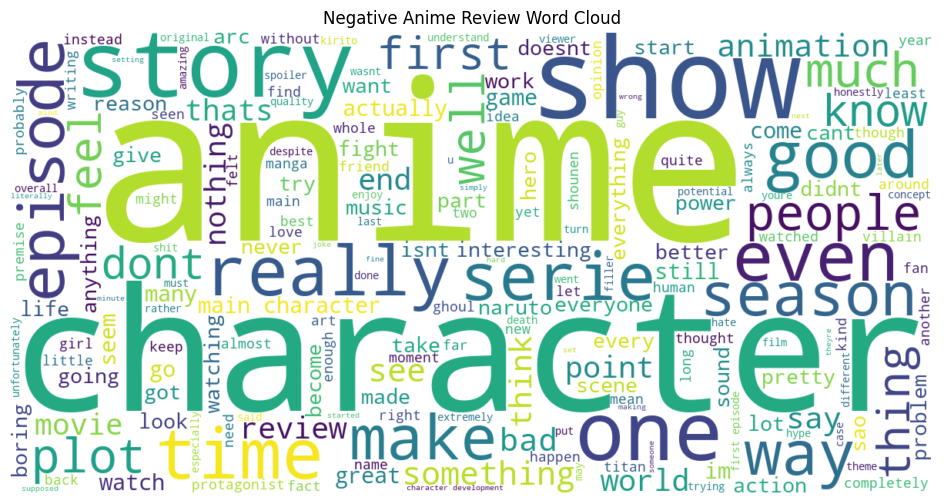

In [32]:
plt.figure(figsize=(12, 6))

plt.imshow(
    negative_wc,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Negative Anime Review Word Cloud"
)

plt.show()

In [33]:
coef_df.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

In [34]:
import os

os.path.exists(
    "../data/processed/feature_importance.csv"
)

True

In [35]:
coef_df.shape

(1000, 2)

In [36]:
df.to_csv(
    "../data/processed/anime_reviews_processed.csv",
    index=False
)

In [37]:
df = pd.read_csv("data/processed/anime_reviews_processed.csv")

print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/anime_reviews_processed.csv'

In [38]:
import os

print(os.getcwd())

/Users/manaskolaskar/Developer/Projects/otaku-ai/notebooks


In [39]:
import os

print(os.listdir("../data/processed"))

['feature_importance.csv', 'anime_reviews_processed.csv']


In [40]:
df = pd.read_csv("../data/processed/anime_reviews_processed.csv")

print(df.columns.tolist())

['review_id', 'anime_mal_id', 'anime_title', 'username', 'score', 'tags', 'review_text', 'date', 'episodes_watched', 'is_spoiler', 'is_preliminary', 'reactions_overall', 'reactions_nice', 'reactions_love_it', 'reactions_funny', 'reactions_confusing', 'reactions_informative', 'reactions_well_written', 'reactions_creative']


In [41]:
print(df.columns.tolist())

['review_id', 'anime_mal_id', 'anime_title', 'username', 'score', 'tags', 'review_text', 'date', 'episodes_watched', 'is_spoiler', 'is_preliminary', 'reactions_overall', 'reactions_nice', 'reactions_love_it', 'reactions_funny', 'reactions_confusing', 'reactions_informative', 'reactions_well_written', 'reactions_creative']


In [42]:
df["review_length"] = df["review_text"].str.len()

df["binary_sentiment"] = df["score"].apply(
    lambda x: "Positive" if x >= 7 else "Negative"
)

In [43]:
df.to_csv(
    "../data/processed/anime_reviews_processed.csv",
    index=False
)

In [44]:
df.shape

(1490, 21)

In [45]:
df.columns.tolist()

['review_id',
 'anime_mal_id',
 'anime_title',
 'username',
 'score',
 'tags',
 'review_text',
 'date',
 'episodes_watched',
 'is_spoiler',
 'is_preliminary',
 'reactions_overall',
 'reactions_nice',
 'reactions_love_it',
 'reactions_funny',
 'reactions_confusing',
 'reactions_informative',
 'reactions_well_written',
 'reactions_creative',
 'review_length',
 'binary_sentiment']

In [46]:
import pandas as pd

check_df = pd.read_csv(
    "../data/processed/anime_reviews_processed.csv"
)

print(check_df.columns.tolist())

['review_id', 'anime_mal_id', 'anime_title', 'username', 'score', 'tags', 'review_text', 'date', 'episodes_watched', 'is_spoiler', 'is_preliminary', 'reactions_overall', 'reactions_nice', 'reactions_love_it', 'reactions_funny', 'reactions_confusing', 'reactions_informative', 'reactions_well_written', 'reactions_creative', 'review_length', 'binary_sentiment']
